# Parameterized Neural Network (PNN) — 1l2tau, Run 2

A **PNN** is an ordinary feed-forward classifier that additionally takes a
"theory parameter" as a plain input feature, so a single trained network can
stand in for a whole family of specialized classifiers (Baldi, Cranmer,
Faucett, Gross & Whiteson, *Parameterizing the Learning of a Neural
Network*, 2016). The classic use case parameterizes on a resonance **mass**
- but these ROOT files have no per-event mass branch (only one file per
production mode: `signal_ggF.root` / `signal_VBF.root`, no mass points), so
that doesn't apply here.

Instead this notebook parameterizes on **production mode** (ggF vs VBF), a
discrete 0/1 analogue of the same trick: signal events get their true
production-mode label as an extra input column (`param_is_VBF`); background
events - which have no genuine "production mode" - are randomly assigned a
value drawn from the signal sample's own mix, so the network never sees the
parameter as a trivial signal/background tell. At inference time, fixing
`param_is_VBF` to 0 or 1 for every event asks the *same* trained network
"how would a ggF-optimized (resp. VBF-optimized) classifier score this
event?" without retraining - validated at the end of this notebook.

**Scope of this first pass:** Run 2 only, single track (no Run 3/Combined
yet, no correlation-pruning/top-15 stage) - data loading, split, model,
training, evaluation, permutation importance, physics figure-of-merit +
held-out test evaluation, and the PNN-specific parameterized-inference
validation. Reuses the exact same `discover_common_features` /
`load_run_data` / `clean_data` / leakage-blocklist / `make_3way_split`
policy as `DNN.ipynb` and `1L2Tau_Master_Pipeline.ipynb`, so results are
directly comparable to those baselines.


## Libraries

In [1]:
import os

# Must be set BEFORE CUDA/cuBLAS initializes for deterministic cuBLAS matmul.
# If this kernel already has CUDA initialized (e.g. you've run cells before
# adding this), these two env vars won't take effect until you RESTART THE
# KERNEL.

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

RANDOM_STATE = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE):

    """
    Full determinism, not just seeding: also pins cuDNN to deterministic
    kernels, disables its autotuner, and asks torch to error out (rather than
    silently fall back) on any op without a deterministic implementation.
    Determinism is only guaranteed on the SAME machine / CUDA / torch
    version - it is not portable across hardware or library versions.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


set_seed(RANDOM_STATE)

print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
# ---------------------------------------------------------------------------
# Paths - 1 lepton + 2 taus, Run 2 only (same source files as
# Final_Notebooks/DNN.ipynb's Run 2 track, so results are directly comparable).
# ---------------------------------------------------------------------------

BASE_DIR_RUN2 = Path("PPSSP_2026/1l2tau/run2")
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"
TREE_NAME = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "1 Lepton 2 Taus")
# ---------------------------------------------------------------------------

PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background)
# ---------------------------------------------------------------------------

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]  # raw branches; w_phys = their product

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy (identical to the XGBoost/MLP/DNN
# 1l2tau pipelines, so all models see the same information).
# ---------------------------------------------------------------------------

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT = {
    "n_b_jet", "pass1l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig", "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode", "tau1_nprong", "tau2_nprong"
}

BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:

    """True if `branch` is safe to use as a training feature (see policy above)."""

    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)

## Data Loading Helpers

In [3]:
def discover_common_features(base_dir, files=FILES, tree_name=TREE_NAME):
    
    """
    Branches common to EVERY process file in `base_dir`, filtered through`is_feature`.
    """

    common = None

    for fname, _ in files.values():
        keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
        common = keys if common is None else common & keys

    features = sorted(b for b in common if is_feature(b))

    print(f"{len(features)} candidate features (common to all {len(files)} processes, leakage-free)")

    return features


def load_run_data(base_dir, features, files=FILES, weight_parts=WEIGHT_PARTS,
                   preselection=PRESELECTION, tree_name=TREE_NAME, verbose=True):

    """
    Read every process file under `base_dir`, apply the preselection at
    read time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
    """

    base_dir = Path(base_dir)
    dfs = []

    for proc, (fname, label) in files.items():

        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts, cut=preselection, library="pd")
        df["w_phys"] =  df["weights"] * df["weight"]
        df["label"] = label
        df["process"] = proc
        dfs.append(df)

        if verbose:
            print(f"{proc:12s}: {len(df):>8d} events after preselection")

    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):

    """
    Post-concat cleaning: drop constant/empty features, then mask sentinel
    values (< -100, e.g. -999) to NaN. Returns (cleaned_data, updated_features);
    operates on a copy, does not mutate the input DataFrame.
    """

    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)
    
    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
              f"background = {(data.label==0).sum()}")
        print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
              f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features

## Load Run 2 Data

In [4]:
candidate_features = discover_common_features(BASE_DIR_RUN2)
data = load_run_data(BASE_DIR_RUN2, candidate_features)
data, features = clean_data(data, candidate_features)

81 candidate features (common to all 10 processes, leakage-free)
signal_ggF  :    67075 events after preselection
signal_VBF  :    21639 events after preselection
Diboson     :   312600 events after preselection
Zjets       :   141863 events after preselection
Wjets       :    31272 events after preselection
ttbar       :     7335 events after preselection
tops        :    62238 events after preselection
SingleH     :    11124 events after preselection
Vgamma      :    21510 events after preselection
VVV         :    14028 events after preselection
Dropped 17 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_passOR']

64 final features
Total: 690684 events | signal = 88714 | background = 601970
Yield (w_phys): signal = 1.82 | background = 11467.29


## PNN Parameter: Production Mode (ggF vs VBF)

`param_is_VBF` is a new *engineered* input column, not a physics branch - it
is added directly to `data`, added to the model's input, and deliberately
kept out of `features` (so the leakage blocklist / sentinel audit /
correlation-pruning machinery below never touches it, it's always available
to the network).

- **Signal events** get their TRUE production mode: 1 if `process ==
  "signal_VBF"`, 0 if `process == "signal_ggF"`.
- **Background events** have no genuine production mode, so - following the
  standard parameterized-NN training trick (Baldi et al. 2016, originally
  for a continuous mass parameter) - each is randomly assigned a value drawn
  from a `Bernoulli(p)` where `p` = the fraction of VBF among signal events.
  This keeps the parameter's marginal distribution the same for signal and
  background, so the network can't use `param_is_VBF` alone as a trivial
  signal/background tell - it only becomes useful in combination with the
  kinematic features (e.g. favoring high-`m_jj`/forward-jet topologies when
  `param_is_VBF = 1`).

At inference, fixing `param_is_VBF` to 0 or 1 for every event lets the same
trained network stand in for a ggF-optimized or VBF-optimized classifier -
validated in the "Parameterized Inference Validation" section at the end.

In [5]:
def assign_pnn_parameter(data, seed=RANDOM_STATE):

    """
    Adds `param_is_VBF` (float, 0/1) to `data`: the TRUE production mode for
    signal events, and a value drawn from Bernoulli(p = signal's VBF
    fraction) for background events (which have no genuine production
    mode). Operates on a copy, does not mutate the input DataFrame.
    """

    rng = np.random.default_rng(seed)
    data = data.copy()

    is_signal = data["label"] == 1
    is_vbf_signal = data["process"] == "signal_VBF"

    data["param_is_VBF"] = 0.0
    data.loc[is_signal, "param_is_VBF"] = is_vbf_signal[is_signal].astype(float)

    p_vbf = float(is_vbf_signal[is_signal].mean())
    n_bkg = int((~is_signal).sum())
    data.loc[~is_signal, "param_is_VBF"] = rng.binomial(1, p_vbf, size=n_bkg).astype(float)

    n_ggf_sig = int((is_signal & ~is_vbf_signal).sum())
    n_vbf_sig = int((is_signal & is_vbf_signal).sum())
    n_bkg_vbf = int(data.loc[~is_signal, "param_is_VBF"].sum())

    print(f"Signal parameter mix: P(VBF) = {p_vbf:.3f}  (ggF signal = {n_ggf_sig}, VBF signal = {n_vbf_sig})")
    print(f"Background ({n_bkg} events) randomly assigned param_is_VBF ~ Bernoulli({p_vbf:.3f}) "
          f"-> {n_bkg_vbf} set to 1 (VBF-like), {n_bkg - n_bkg_vbf} set to 0 (ggF-like)")

    return data


data = assign_pnn_parameter(data)

Signal parameter mix: P(VBF) = 0.244  (ggF signal = 67075, VBF signal = 21639)
Background (601970 events) randomly assigned param_is_VBF ~ Bernoulli(0.244) -> 146647 set to 1 (VBF-like), 455323 set to 0 (ggF-like)


## Sentinel Audit (-1)

`clean_data` only masks `< -100` sentinels (e.g. `-999`) to NaN. Some ATLAS
branches instead default to exactly `-1` for "undefined", which `clean_data`
would otherwise treat as a legitimate physical value. `-1` is also a
perfectly valid value for plenty of other branches (e.g. charges), so it
must **not** be blanket-masked - only branches where `-1` is a genuine
"undefined" sentinel (a spike at `-1` detached from the rest of the
distribution, with a gap just above it) should be added to
`NEG1_SENTINEL_FEATURES` below. The diagnostic cell prints, per feature, the
fraction of rows exactly equal to `-1` and the gap to the next-smallest
value above `-1`, to help build that set by inspection - it does not decide
automatically.

In [6]:
NEG1_SENTINEL_FEATURES = set()

neg1_rows = []

for f in features:
    vals = data[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df = pd.DataFrame(neg1_rows).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df)} / {len(features)} features have at least one row exactly equal to -1:")
print(neg1_df.to_string(index=False))

# Apply the (currently empty) mask before the train/val/test split, so any
# features added to NEG1_SENTINEL_FEATURES later automatically flow into
# both the median-imputation and the missingness flags below.

for f in NEG1_SENTINEL_FEATURES:
    data[f] = data[f].mask(data[f] == -1)
    
if NEG1_SENTINEL_FEATURES:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES)}")
else:
    print("\nNEG1_SENTINEL_FEATURES is empty - no -1 values masked.")

1 / 64 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474042                      2.0

NEG1_SENTINEL_FEATURES is empty - no -1 values masked.


## Train/Validation/Test Split & Preprocessing

Deterministic two-stage stratified **80/10/10** train/val/test split
(`make_3way_split`) - IDENTICAL logic/seed to `DNN.ipynb`/
`1L2Tau_Master_Pipeline.ipynb`'s `make_3way_split` (stratified on `label`
only, so all three notebooks land on byte-identical partitions at the same
`BASE_DIR_RUN2`). **TEST is held out**: it does not participate in the
median imputation, the `StandardScaler` fit, `flag_cols`, early stopping, or
the significance-scan score-cut selection below - it is only read once, in
the "Held-Out Test Evaluation" cell near the end.

`param_is_VBF` rides along as an ordinary column of `data`/`train_df`/
`val_df`/`test_df` (added before the split, so no extra plumbing is
needed here) and is appended, **unscaled** (it is already 0/1), right after
the scaled physics features - `MODEL_FEATURES = features + ["param_is_VBF"]`
is the canonical name list for the model's input columns.

Neural nets (unlike XGBoost) can't handle NaN natively, so sentinel-masked
physics values are median-imputed (fit on the train split only) before
standard scaling; missingness itself is preserved via `__isnan` flag
columns (schema derived from train only, also unscaled). Training weights
are class-balanced and mean-normalized; validation/test weights stay as
plain `|w_phys|`. Per the supervisor's project-wide policy, negative-`w_phys`
training events are dropped entirely (not abs'd) before fitting.

In [7]:
def make_fit_weights(labels, abs_weights):

    """
    Balance signal/background total weight and normalize the mean weight
    to 1. `abs_weights` must already be non-negative (Sherpa weights can be
    negative).
    """

    labels = np.asarray(labels)

    fit_weights = np.asarray(abs_weights, dtype=float).copy()
    sum_signal = fit_weights[labels == 1].sum()
    sum_background = fit_weights[labels == 0].sum()
    fit_weights[labels == 1] *= sum_background / sum_signal
    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def make_3way_split(data, test_size=0.10, val_size=0.10, seed=RANDOM_STATE, extra_stratify_col=None):

    """
    Deterministic two-stage stratified 80/10/10 train/val/test split -
    IDENTICAL logic (same seed, same stratify) to DNN.ipynb's
    make_3way_split, so both notebooks land on byte-identical partitions
    whenever they build `data` the same way (same FILES order -> concat ->
    clean_data). `param_is_VBF` is NOT part of the stratification here, by
    design - stratifying on it would change the split versus the sibling
    notebooks that share this same BASE_DIR_RUN2 test partition.

    TEST must not participate in anything until it is scored exactly once at
    the very end: not the median imputation, not the StandardScaler fit,
    not `flag_cols`, not early stopping, not the significance-scan score-cut
    selection.

    Stage 1 peels off `test_size` (10%) as TEST. Stage 2 splits the
    remaining (1 - test_size) into train/val; to get `val_size` (10%) OF THE
    FULL SAMPLE, stage 2's test_size must be val_size / (1 - test_size) =
    0.10 / 0.90 = 1/9, NOT val_size itself.
    """

    def _strata(df):
        if extra_stratify_col is not None:
            return df["label"].astype(str) + "_" + df[extra_stratify_col].astype(str)
        return df["label"]

    trainval_df, test_df = train_test_split(data, test_size=test_size, random_state=seed, stratify=_strata(data))

    val_frac_of_remaining = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        trainval_df, test_size=val_frac_of_remaining, random_state=seed, stratify=_strata(trainval_df)
    )

    for name, df in (("Train", train_df), ("Val", val_df), ("Test", test_df)):
        sig_n, bkg_n = int((df.label == 1).sum()), int((df.label == 0).sum())
        sig_y = df.loc[df.label == 1, "w_phys"].sum()
        bkg_y = df.loc[df.label == 0, "w_phys"].sum()
        print(f"{name:5s}: {len(df):>8d} events | signal = {sig_n:>7d} (yield={sig_y:>10.2f}) | "
              f"background = {bkg_n:>7d} (yield={bkg_y:>10.2f}) | "
              f"signal weight scale factor = {bkg_y / sig_y:.1f}")

    return train_df, val_df, test_df


def assert_same_test_partition(test_df, path):

    """
    Cross-notebook guard: if a test partition already exists on disk at
    `path` (e.g. written by DNN.ipynb / 1L2Tau_Master_Pipeline.ipynb reading
    the exact same BASE_DIR), verify this notebook's freshly-computed
    `test_df` is byte-identical to it on their SHARED columns
    (`param_is_VBF` is unique to this notebook, so it's simply excluded from
    the comparison via the column intersection below - no conflict).
    """

    path = Path(path)
    if not path.exists():
        print(f"  (no prior test partition at {path} yet - nothing to cross-check)")
        return

    prior_df = uproot.open({str(path): "tree"}).arrays(library="pd")
    cols = sorted((set(test_df.columns) & set(prior_df.columns)) - {"run"})
    a = test_df[cols].sort_values(cols).reset_index(drop=True)
    b = prior_df[cols].sort_values(cols).reset_index(drop=True)

    pd.testing.assert_frame_equal(a, b, check_exact=False, rtol=1e-5, atol=1e-8, check_dtype=False)
    print(f"  cross-check OK: {path} test partition matches on {len(cols)} shared columns ({len(test_df)} rows)")


def persist_test_partition(test_df, split_dir):

    """
    Persist just TEST to disk under `split_dir` (train/val are already
    written by the sibling XGBoost/MLP/DNN notebooks sharing BASE_DIR_RUN2)
    - cross-checks against any prior test.root there first.
    """

    split_dir = Path(split_dir)
    split_dir.mkdir(parents=True, exist_ok=True)
    test_path = split_dir / "test.root"
    assert_same_test_partition(test_df, test_path)
    with uproot.recreate(test_path) as f:
        f["tree"] = test_df.reset_index(drop=True)
    print(f"Wrote {len(test_df)} test events -> {test_path}  (held out until final evaluation)")


train_df, val_df, test_df = make_3way_split(data)

SPLIT_DIR_RUN2 = BASE_DIR_RUN2 / "splits"
persist_test_partition(test_df, SPLIT_DIR_RUN2)

Train:   552546 events | signal =   70971 (yield=      1.46) | background =  481575 (yield=   9202.46) | signal weight scale factor = 6316.7
Val  :    69069 events | signal =    8872 (yield=      0.18) | background =   60197 (yield=   1129.19) | signal weight scale factor = 6142.7
Test :    69069 events | signal =    8871 (yield=      0.18) | background =   60198 (yield=   1135.64) | signal weight scale factor = 6181.7
  cross-check OK: PPSSP_2026/1l2tau/run2/splits/test.root test partition matches on 69 shared columns (69069 rows)
Wrote 69069 test events -> PPSSP_2026/1l2tau/run2/splits/test.root  (held out until final evaluation)


In [8]:
X_train_raw, y_train, w_train = train_df[features], train_df["label"].to_numpy(), train_df["w_phys"].to_numpy()
X_val_raw,   y_val,   w_val   = val_df[features],   val_df["label"].to_numpy(),   val_df["w_phys"].to_numpy()
X_test_raw,  y_test,  w_test  = test_df[features],  test_df["label"].to_numpy(),  test_df["w_phys"].to_numpy()

param_train = train_df["param_is_VBF"].to_numpy(dtype=np.float32).reshape(-1, 1)
param_val = val_df["param_is_VBF"].to_numpy(dtype=np.float32).reshape(-1, 1)
param_test = test_df["param_is_VBF"].to_numpy(dtype=np.float32).reshape(-1, 1)

# ---- Missingness indicator flags (schema derived from TRAIN only) ---------
nan_train = X_train_raw.isna()
flag_cols = nan_train.columns[nan_train.any()].tolist()


def make_flags(X_raw):
    """0/1 missingness flags for `flag_cols`, kept unscaled - scaling a 0/1
    flag would just relabel it, not add information."""
    f = X_raw[flag_cols].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols]
    return f


# Median imputation (fit on train only), then standard scaling (fit on train
# only). TEST is only ever transformed with these already-frozen train
# statistics, never used to fit them. `param_is_VBF` is stacked in RIGHT
# AFTER the scaled physics features (unscaled, already 0/1) - MODEL_FEATURES
# below is the canonical name list for those columns; any __isnan flags
# trail after and are simply not addressed by name (matches DNN.ipynb's
# convention, and there are currently 0 flags for this dataset anyway).

train_medians = X_train_raw.median()
X_train_imp = X_train_raw.fillna(train_medians)
X_val_imp = X_val_raw.fillna(train_medians)
X_test_imp = X_test_raw.fillna(train_medians)

scaler = StandardScaler()
X_train_scaled = np.hstack([scaler.fit_transform(X_train_imp), param_train, make_flags(X_train_raw).to_numpy()])
X_val_scaled = np.hstack([scaler.transform(X_val_imp), param_val, make_flags(X_val_raw).to_numpy()])
X_test_scaled = np.hstack([scaler.transform(X_test_imp), param_test, make_flags(X_test_raw).to_numpy()])

MODEL_FEATURES = features + ["param_is_VBF"]

assert np.isfinite(X_train_scaled).all(), "NaN/inf reached the model input (train)"
assert np.isfinite(X_val_scaled).all(), "NaN/inf reached the model input (val)"
assert np.isfinite(X_test_scaled).all(), "NaN/inf reached the model input (test)"

print(f"\n{len(flag_cols)} features had missing values in train -> added {len(flag_cols)} __isnan flag "
      f"columns (final input width = {X_train_scaled.shape[1]} = {len(features)} features + 1 PNN "
      f"parameter + {len(flag_cols)} flags)")

# Training weights: per the supervisor's instruction, events with negative
# w_phys are DROPPED from the training set entirely (not abs'd/imputed).
# X_train_scaled already has param_train stacked in, so this filter keeps
# everything row-aligned automatically. Validation/test are untouched and
# still use |w_phys| for early stopping / AUC.

train_neg_mask = w_train < 0
n_dropped = int(train_neg_mask.sum())
print(f"Dropped {n_dropped}/{len(w_train)} negative-w_phys training events "
      f"({n_dropped / len(w_train):.1%}) - kept, not abs'd")

X_train_scaled = X_train_scaled[~train_neg_mask]
y_train = y_train[~train_neg_mask]
w_train = w_train[~train_neg_mask]  # already non-negative post-filter

w_train_fit = make_fit_weights(y_train, w_train)
w_train_abs = w_train  # non-negative post-filter; eval-mode "comparable" train curves

# Validation weights for AUC: plain |w_phys| so AUC reflects the true class balance.
w_val_fit = np.abs(w_val)

# Test weights: plain |w_phys| too - test is only ever scored once, at the
# very end, so there is no "fit" version needed.
w_test_fit = np.abs(w_test)

print(f"Signal weight scale factor (train, post-filter): "
      f"{w_train[y_train==0].sum() / w_train[y_train==1].sum():.1f}")


0 features had missing values in train -> added 0 __isnan flag columns (final input width = 65 = 64 features + 1 PNN parameter + 0 flags)
Dropped 59471/552546 negative-w_phys training events (10.8%) - kept, not abs'd
Signal weight scale factor (train, post-filter): 7709.7


## PyTorch Dataset & Model (ParameterizedNN)

Architecturally this is an ordinary feed-forward binary classifier - the
"parameterization" comes entirely from `param_is_VBF` being just another
input dimension (per Baldi/Cranmer/Whiteson), not from any special layer or
loss. `hidden_sizes=(256, 128)` reuses the architecture that already won a
hidden-size grid search for this exact 1l2tau Run 2 feature/data setup (see
`MLP.ipynb`) - skipped here again for this first, simpler pass.

In [9]:
# Model input is small enough to comfortably fit in GPU memory - keep it
# resident there for the whole run instead of using a DataLoader, which
# would otherwise copy every mini-batch host->device one at a time. Batches
# are then just GPU-side tensor indexing (see run_epoch).

BATCH_SIZE = 8192

DEFAULT_HIDDEN_SIZES = (256, 128)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)
w_train_t = torch.tensor(w_train_fit, dtype=torch.float32, device=DEVICE)
w_train_abs_t = torch.tensor(w_train_abs, dtype=torch.float32, device=DEVICE)  # |w_phys|, dropout-off "eval-mode" train weights

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)
w_val_t = torch.tensor(w_val_fit, dtype=torch.float32, device=DEVICE)

# TEST is only ever read once, in the "Held-Out Test Evaluation" cell near
# the end - kept GPU-resident here purely for consistency with train/val.
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32, device=DEVICE)
w_test_t = torch.tensor(w_test_fit, dtype=torch.float32, device=DEVICE)


class ParameterizedNN(nn.Module):

    """
    A PNN classifier: same feed-forward architecture as a plain MLP (hidden
    layers with ReLU + dropout, single output logit paired with
    BCEWithLogitsLoss), the only difference is that its input already
    includes the PNN parameter (`param_is_VBF`) as an ordinary extra column
    - there is nothing parameter-specific in the architecture itself.
    """

    def __init__(self, n_features, hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3):

        super().__init__()
        layers = []
        in_size = n_features

        for hidden_size in hidden_sizes:

            layers += [nn.Linear(in_size, hidden_size), nn.ReLU(), nn.Dropout(dropout)]
            in_size = hidden_size

        layers.append(nn.Linear(in_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def build_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, n_features=None):

    """
    Factory so a hyperparameter search (or a feature-subset retrain) can
    build a fresh model per trial without repeating the
    ParameterizedNN(...).to(DEVICE) boilerplate. `n_features` defaults to
    the full input width (physics features + PNN parameter + missingness
    flags).
    """

    if n_features is None:
        n_features = X_train_scaled.shape[1]
    return ParameterizedNN(n_features=n_features, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)


model = build_model()

print(model)

ParameterizedNN(
  (net): Sequential(
    (0): Linear(in_features=65, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)


## Training Loop

Weighted binary cross-entropy (per-sample weights folded in manually, since
`BCEWithLogitsLoss` has no built-in sample-weight argument), Adam optimizer,
early stopping on weighted validation AUC.

In [10]:
N_EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 1e-3


def run_epoch(model, X, y, w, criterion, optimizer, train, batch_size=BATCH_SIZE):

    """
    One pass over the GPU-resident tensors (X, y, w), split into
    `batch_size` chunks via plain tensor indexing (no DataLoader). Loss/
    predictions are only pulled to the CPU once, at the very end of the
    epoch, instead of calling `.item()`/`.cpu()` inside the loop (which
    would force a CPU<->GPU sync every mini-batch and stall the GPU).
    """

    model.train(train)
    n = X.shape[0]
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)

    total_loss = torch.zeros((), device=DEVICE)
    total_weight = torch.zeros((), device=DEVICE)
    all_labels, all_probs, all_weights = [], [], []

    with torch.set_grad_enabled(train):
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb, yb, wb = X[idx], y[idx], w[idx]

            logits = model(xb)
            loss = (criterion(logits, yb) * wb).sum() / wb.sum()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.detach() * wb.sum()
            total_weight += wb.sum()
            all_labels.append(yb.detach())
            all_probs.append(torch.sigmoid(logits).detach())
            all_weights.append(wb.detach())

    labels = torch.cat(all_labels).cpu().numpy()
    probs = torch.cat(all_probs).cpu().numpy()
    weights = torch.cat(all_weights).cpu().numpy()

    auc = roc_auc_score(labels, probs, sample_weight=weights)

    return (total_loss / total_weight).item(), auc


def train_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, lr=LEARNING_RATE,
                 n_epochs=N_EPOCHS, patience=PATIENCE, verbose=True,
                 X_train_data=None, y_train_data=None, w_train_data=None,
                 X_val_data=None, y_val_data=None, w_val_data=None,
                 w_train_eval_data=None):

    """
    Build a fresh ParameterizedNN(hidden_sizes, dropout) and train it with
    early stopping on weighted validation AUC. Data args default to the
    full-input GPU-resident tensors (X_train_t/y_train_t/w_train_t/
    X_val_t/y_val_t/w_val_t).

    Every epoch also runs an EVAL-MODE pass over the training data (dropout
    off, plain |w_phys| weights via `w_train_eval_data`, default
    `w_train_abs_t`) - "train_auc_eval"/"train_loss_eval" are directly
    comparable to the val curve (dropout off, |w_phys|), unlike the
    dropout-ON "train_auc"/"train_loss" the optimizer actually sees.

    Returns (model, history, best_val_auc, best_train_auc, best_train_auc_eval)
    - `model` already has the best-epoch weights loaded.
    """

    X_train_data = X_train_t if X_train_data is None else X_train_data
    y_train_data = y_train_t if y_train_data is None else y_train_data
    w_train_data = w_train_t if w_train_data is None else w_train_data
    X_val_data = X_val_t if X_val_data is None else X_val_data
    y_val_data = y_val_t if y_val_data is None else y_val_data
    w_val_data = w_val_t if w_val_data is None else w_val_data
    w_train_eval_data = w_train_abs_t if w_train_eval_data is None else w_train_eval_data

    trial_model = build_model(hidden_sizes=hidden_sizes, dropout=dropout, n_features=X_train_data.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_loss_eval": [], "train_auc_eval": []}
    best_val_auc, best_train_auc, best_train_auc_eval = -np.inf, None, None
    best_state, epochs_no_improve = None, 0

    for epoch in range(1, n_epochs + 1):

        train_loss, train_auc = run_epoch(trial_model, X_train_data, y_train_data, w_train_data, criterion, optimizer, train=True)
        train_loss_eval, train_auc_eval = run_epoch(trial_model, X_train_data, y_train_data, w_train_eval_data, criterion, optimizer, train=False)
        val_loss, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss_eval"].append(train_loss_eval)
        history["train_auc_eval"].append(train_auc_eval)

        if verbose:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"| train_auc={train_auc:.4f} train_auc_eval={train_auc_eval:.4f} val_auc={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc, best_train_auc, best_train_auc_eval = val_auc, train_auc, train_auc_eval
            best_state, epochs_no_improve = {k: v.clone() for k, v in trial_model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    trial_model.load_state_dict(best_state)
    return trial_model, history, best_val_auc, best_train_auc, best_train_auc_eval


model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model(hidden_sizes=DEFAULT_HIDDEN_SIZES)

print(f"\nBest val_auc = {best_val_auc:.4f} | train_auc (dropout on) = {best_train_auc:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval:.4f}")

Epoch   1 | train_loss=0.4619 val_loss=0.3290 | train_auc=0.8678 train_auc_eval=0.9116 val_auc=0.9149
Epoch   2 | train_loss=0.3805 val_loss=0.3727 | train_auc=0.9103 train_auc_eval=0.9227 val_auc=0.9234
Epoch   3 | train_loss=0.3646 val_loss=0.3262 | train_auc=0.9179 train_auc_eval=0.9268 val_auc=0.9259
Epoch   4 | train_loss=0.3558 val_loss=0.3195 | train_auc=0.9219 train_auc_eval=0.9301 val_auc=0.9283
Epoch   5 | train_loss=0.3481 val_loss=0.3391 | train_auc=0.9255 train_auc_eval=0.9323 val_auc=0.9303
Epoch   6 | train_loss=0.3451 val_loss=0.3433 | train_auc=0.9268 train_auc_eval=0.9341 val_auc=0.9313
Epoch   7 | train_loss=0.3419 val_loss=0.3181 | train_auc=0.9282 train_auc_eval=0.9354 val_auc=0.9325
Epoch   8 | train_loss=0.3371 val_loss=0.3125 | train_auc=0.9302 train_auc_eval=0.9366 val_auc=0.9333
Epoch   9 | train_loss=0.3348 val_loss=0.3014 | train_auc=0.9312 train_auc_eval=0.9377 val_auc=0.9335
Epoch  10 | train_loss=0.3316 val_loss=0.3248 | train_auc=0.9326 train_auc_eval=0.

## Evaluation

Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2TrainingCurves_PNN.png


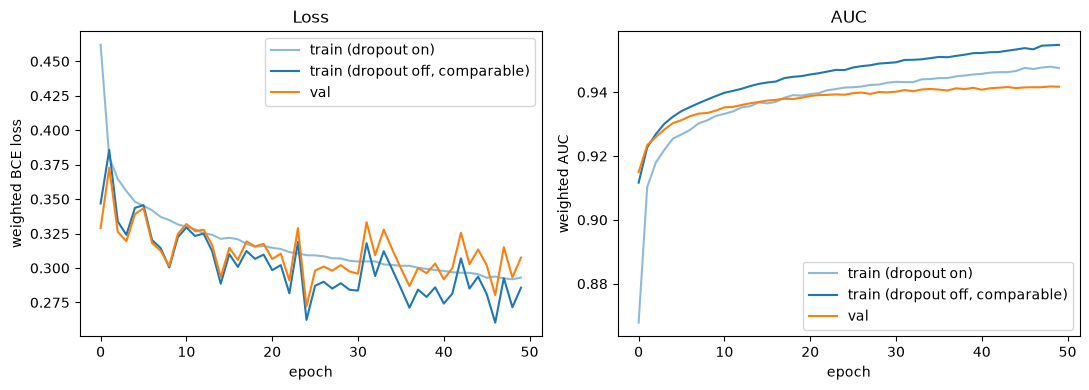

Final weighted AUC: train=0.9547 val=0.9418
Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2ROC_PNN.png


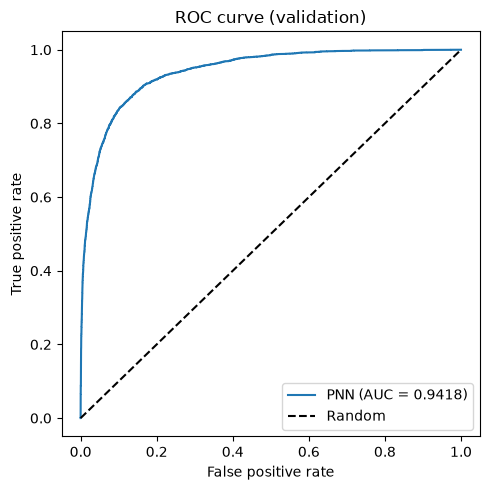

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()

PLOTS_DIR_R2 = BASE_DIR_RUN2 / "plots"
PLOTS_DIR_R2.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOTS_DIR_R2 / "Run2TrainingCurves_PNN.png", dpi=150)
print(f"Saved plot -> {PLOTS_DIR_R2 / 'Run2TrainingCurves_PNN.png'}")
plt.show()

model.eval()
with torch.no_grad():
    train_probs = torch.sigmoid(model(torch.tensor(X_train_scaled, dtype=torch.float32).to(DEVICE))).cpu().numpy()
    val_probs = torch.sigmoid(model(torch.tensor(X_val_scaled, dtype=torch.float32).to(DEVICE))).cpu().numpy()

auc_train = roc_auc_score(y_train, train_probs, sample_weight=np.abs(w_train))
auc_val = roc_auc_score(y_val, val_probs, sample_weight=w_val_fit)

print(f"Final weighted AUC: train={auc_train:.4f} val={auc_val:.4f}")

fpr, tpr, _ = roc_curve(y_val, val_probs, sample_weight=w_val_fit)
fig = plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"PNN (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation)")
plt.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR_R2 / "Run2ROC_PNN.png", dpi=150)
print(f"Saved plot -> {PLOTS_DIR_R2 / 'Run2ROC_PNN.png'}")
plt.show()

## Feature Importance (Permutation)

Model-agnostic **permutation importance**: shuffle one feature's column
across events (destroying its relationship with the rest of the row) and
measure how much the weighted validation AUC drops. `param_is_VBF` is
included as an ordinary entry in `MODEL_FEATURES` here - a large drop when
it's shuffled would confirm the network genuinely uses the PNN parameter
(rather than ignoring it and just relying on the physics features).

Baseline weighted AUC: 0.9418
Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2ImportanceFull_PNN.png


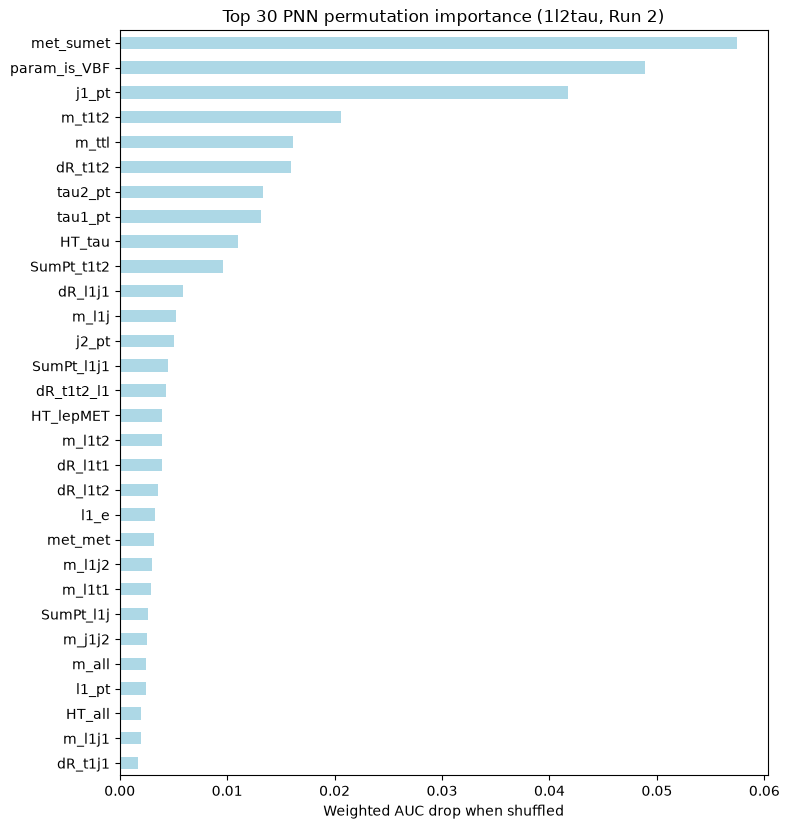


param_is_VBF: rank 2/65, AUC drop = 0.0489


met_sumet       0.057436
param_is_VBF    0.048930
j1_pt           0.041751
m_t1t2          0.020608
m_ttl           0.016133
dR_t1t2         0.015960
tau2_pt         0.013351
tau1_pt         0.013182
HT_tau          0.010983
SumPt_t1t2      0.009610
dR_l1j1         0.005882
m_l1j           0.005266
j2_pt           0.005098
SumPt_l1j1      0.004482
dR_t1t2_l1      0.004284
Name: auc_drop, dtype: float64

In [12]:
def permutation_importance(model, X, y, w, feature_names, n_repeats=5, random_state=RANDOM_STATE):

    """
    Model-agnostic feature importance: for each feature, shuffle its column
    across events `n_repeats` times and measure the average drop in weighted
    AUC relative to the unshuffled baseline. `X`, `y`, `w` must already be
    GPU-resident tensors with columns in the same order as `feature_names`
    (only the FIRST `len(feature_names)` columns of `X` are addressed - any
    trailing `__isnan` flag columns are intentionally left unreported).
    Returns a pandas Series (feature -> mean AUC drop), sorted descending.
    """

    rng = np.random.default_rng(random_state)
    model.eval()

    y_np = y.cpu().numpy()
    w_np = w.cpu().numpy()

    with torch.no_grad():
        baseline_probs = torch.sigmoid(model(X)).cpu().numpy()

    baseline_auc = roc_auc_score(y_np, baseline_probs, sample_weight=w_np)
    print(f"Baseline weighted AUC: {baseline_auc:.4f}")

    mean_drops = []
    
    for i, feat in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            perm = torch.as_tensor(rng.permutation(X.shape[0]), device=X.device)
            X_perm = X.clone()
            X_perm[:, i] = X_perm[perm, i]

            with torch.no_grad():
                probs = torch.sigmoid(model(X_perm)).cpu().numpy()
            auc = roc_auc_score(y_np, probs, sample_weight=w_np)
            drops.append(baseline_auc - auc)

        mean_drops.append(np.mean(drops))

    return pd.Series(mean_drops, index=feature_names, name="auc_drop").sort_values(ascending=False)


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):

    """
    Horizontal bar chart of the top `top_n` features by importance. If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    n = min(top_n, len(imp))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp.head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Weighted AUC drop when shuffled")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()


importance = permutation_importance(model, X_val_t, y_val_t, w_val_t, MODEL_FEATURES, n_repeats=5)
plot_importance_bar(importance, top_n=30, title="Top 30 PNN permutation importance (1l2tau, Run 2)",
                     save_path=PLOTS_DIR_R2 / "Run2ImportanceFull_PNN.png")

param_rank = int(importance.index.get_loc("param_is_VBF")) + 1
print(f"\nparam_is_VBF: rank {param_rank}/{len(importance)}, AUC drop = {importance['param_is_VBF']:.4f}")
importance.head(15)

## Physics Figure of Merit

Weighted AUC is a global ranking metric; for HH what matters is significance
in the high-score region. This reports a max-Asimov-significance scan on
**VAL** (used for model/cut selection) for the full PNN model above.

A genuinely blind estimate follows in the "Held-Out Test Evaluation" cell
below: the VAL-selected score cut is applied FROZEN to the never-before-seen
**TEST** partition (10% of the sample, held out by `make_3way_split` since
before preprocessing), reporting test AUC and test Z at that cut exactly
once.

In [13]:
def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):

    """
    Max Asimov significance over score cuts. Uses SIGNED w_phys (expected
    yields, not |w_phys|). `min_bkg` guards the sparse high-score tail where
    Z is unstable/unphysical when B is tiny or negative. Treat Z as a
    RELATIVE metric for ranking models on the identical rows, not an
    absolute discovery number.
    """

    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None

    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))  # Asimov; -> S/sqrt(B) for S<<B
        if z > best_z:
            best_z, best_t = z, t

    return best_z, best_t


final_model = model  # single full-input (physics + PNN parameter) network; no pruning stage in this first pass

final_model.eval()
with torch.no_grad():
    val_scores = torch.sigmoid(final_model(X_val_t)).cpu().numpy()

z_val, thr_val = significance_scan(y_val, val_scores, w_val)  # signed w_phys - expected yields

print(f"Weighted val AUC = {auc_val:.4f}")
print(f"Max Asimov Z (val) = {z_val:.3f} at score cut = {thr_val:.4f}")

Weighted val AUC = 0.9418
Max Asimov Z (val) = 0.034 at score cut = 0.9874


### Held-Out Test Evaluation

`X_test_t`/`y_test`/`w_test` have not participated in anything above - not
the imputation/scaler fit, not the score-cut selection just above. This is
the one place they are read: the final model is scored once, and the
VAL-selected score cut is applied frozen (not re-scanned).

In [14]:
# ---- HELD-OUT TEST EVALUATION — scored EXACTLY ONCE ------------------------
final_model.eval()
with torch.no_grad():
    test_scores = torch.sigmoid(final_model(X_test_t)).cpu().numpy()

auc_test = roc_auc_score(y_test, test_scores, sample_weight=w_test_fit)

S_test = w_test[(test_scores >= thr_val) & (y_test == 1)].sum()
B_test = w_test[(test_scores >= thr_val) & (y_test == 0)].sum()
z_test = (np.sqrt(2 * ((S_test + B_test) * np.log(1 + S_test / B_test) - S_test))
          if (S_test > 0 and B_test > 0) else np.nan)

print(f"Weighted AUC: val = {auc_val:.4f}  |  test (held-out, scored once) = {auc_test:.4f}")
print(f"At the VAL-selected score cut = {thr_val:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test:.2f} | test B = {B_test:.2f} | test Z = {z_test:.3f}  (val Z was {z_val:.3f})")

Weighted AUC: val = 0.9418  |  test (held-out, scored once) = 0.9463
At the VAL-selected score cut = 0.9874 (frozen, NOT re-scanned on test):
  test S = 0.04 | test B = 1.56 | test Z = 0.030  (val Z was 0.034)


## Parameterized Inference Validation

The defining PNN check: does scoring at a FIXED parameter value make the
network behave like a classifier tuned for that specific signal hypothesis?
For every **validation** event (signal + background - test stays touched
only once, above), `param_is_VBF` is overwritten to 0 (ggF-mode) and to 1
(VBF-mode), re-scoring the SAME trained network both times (no retraining),
and each setting's weighted AUC is compared when restricted to signal from
just that production mode (all-background rows always included). A
well-behaved PNN should show its highest AUC for ggF-only signal when
evaluated at param=0, and its highest AUC for VBF-only signal when evaluated
at param=1 - i.e. the diagonal of the small cross-table below should
dominate.

signal_subset       ggF signal  VBF signal
scored_at                                 
VBF-mode (param=1)      0.8737      0.9251
ggF-mode (param=0)      0.9332      0.8806

ggF signal: AUC at own hypothesis = 0.9332  vs  at VBF hypothesis = 0.8737
VBF signal: AUC at own hypothesis = 0.9251  vs  at ggF hypothesis = 0.8806
PNN check PASSED: each signal process scores best when the network is queried at its own hypothesis.
Saved plot -> PPSSP_2026/1l2tau/run2/plots/Run2PNNValidation_PNN.png


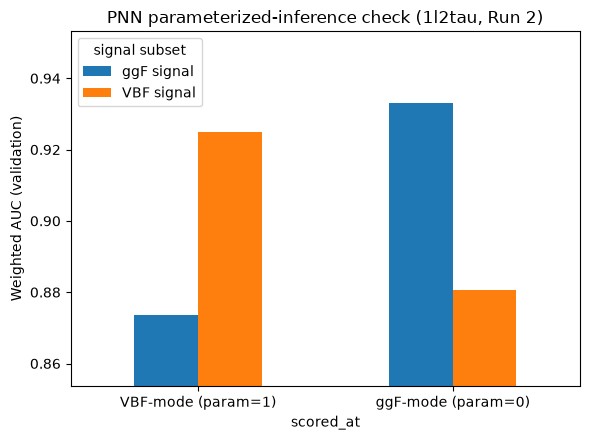

In [15]:
def score_at_fixed_param(model, X_scaled, param_col_idx, param_value):

    """
    Re-score `model` on `X_scaled` (a GPU tensor already containing the
    physics + PNN-parameter + flag columns) after OVERWRITING the parameter
    column with a single fixed value for every row - no retraining, just
    changes which hypothesis the shared network is asked to evaluate under.
    """

    X_fixed = X_scaled.clone()
    X_fixed[:, param_col_idx] = param_value
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(X_fixed)).cpu().numpy()


param_col_idx = MODEL_FEATURES.index("param_is_VBF")

is_ggf_val = (val_df["process"] == "signal_ggF").to_numpy()
is_vbf_val = (val_df["process"] == "signal_VBF").to_numpy()
is_bkg_val = (y_val == 0)

rows = []
for hypothesis_name, hyp_value in [("ggF-mode (param=0)", 0.0), ("VBF-mode (param=1)", 1.0)]:
    scores_fixed = score_at_fixed_param(final_model, X_val_t, param_col_idx, hyp_value)
    for signal_name, signal_mask in [("ggF signal", is_ggf_val), ("VBF signal", is_vbf_val)]:
        sel = signal_mask | is_bkg_val
        auc = roc_auc_score(y_val[sel], scores_fixed[sel], sample_weight=w_val_fit[sel])
        rows.append({"scored_at": hypothesis_name, "signal_subset": signal_name, "weighted_auc": auc})

pnn_validation_df = pd.DataFrame(rows).pivot(index="scored_at", columns="signal_subset", values="weighted_auc")
pnn_validation_df = pnn_validation_df[["ggF signal", "VBF signal"]]
print(pnn_validation_df.to_string(float_format=lambda x: f"{x:.4f}"))

diag_ggf = pnn_validation_df.loc["ggF-mode (param=0)", "ggF signal"]
offdiag_ggf = pnn_validation_df.loc["VBF-mode (param=1)", "ggF signal"]
diag_vbf = pnn_validation_df.loc["VBF-mode (param=1)", "VBF signal"]
offdiag_vbf = pnn_validation_df.loc["ggF-mode (param=0)", "VBF signal"]

print(f"\nggF signal: AUC at own hypothesis = {diag_ggf:.4f}  vs  at VBF hypothesis = {offdiag_ggf:.4f}")
print(f"VBF signal: AUC at own hypothesis = {diag_vbf:.4f}  vs  at ggF hypothesis = {offdiag_vbf:.4f}")

if diag_ggf >= offdiag_ggf and diag_vbf >= offdiag_vbf:
    print("PNN check PASSED: each signal process scores best when the network is queried at its own hypothesis.")
else:
    print("PNN check: at least one process does NOT peak at its own hypothesis - inspect further before trusting the parameterization.")

fig, ax = plt.subplots(figsize=(6, 4.5))
pnn_validation_df.plot.bar(ax=ax, rot=0)
ax.set_ylabel("Weighted AUC (validation)")
ax.set_title("PNN parameterized-inference check (1l2tau, Run 2)")
ax.set_ylim(max(0.5, pnn_validation_df.to_numpy().min() - 0.02), pnn_validation_df.to_numpy().max() + 0.02)
ax.legend(title="signal subset")
plt.tight_layout()
pnn_plot_path = PLOTS_DIR_R2 / "Run2PNNValidation_PNN.png"
fig.savefig(pnn_plot_path, dpi=150)
print(f"Saved plot -> {pnn_plot_path}")
plt.show()

## Sanity Checks & Final Summary

In [16]:
# ---- Sanity checks --------------------------------------------------------

assert np.isfinite(X_train_scaled).all() and np.isfinite(X_val_scaled).all() and np.isfinite(X_test_scaled).all(), \
    "NaN/inf reached the model input"

# Determinism check: re-seeding immediately before each of two short training
# runs should give an EXACT match, proving set_seed()/
# use_deterministic_algorithms(True) actually pin every source of randomness
# (weight init, dropout masks, batch shuffling). Uses a cheap config (small
# model, 5 epochs) purely to keep this check fast.

set_seed(RANDOM_STATE)
_, _, det_check_a, _, _ = train_model(hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False)

set_seed(RANDOM_STATE)
_, _, det_check_b, _, _ = train_model(hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False)
assert det_check_a == det_check_b, f"Determinism check FAILED: {det_check_a} != {det_check_b}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a:.6f}")

# ---- Final summary ---------------------------------------------------------

summary = pd.DataFrame([{
    "model": "PNN (parameterized on production mode)",
    "train_auc_eval": best_train_auc_eval,
    "val_auc": best_val_auc,
    "max_asimov_Z (val)": z_val,
    "test_auc (held-out, scored once)": auc_test,
    "test_Z_at_val_cut (held-out)": z_test,
    "param_auc_own_hypothesis (ggF, VBF)": (diag_ggf, diag_vbf),
}])

print("\nFinal summary (PNN, 1l2tau Run 2):")
print(summary.to_string(index=False))
summary

Determinism check passed: two re-seeded runs give identical val_auc = 0.919683

Final summary (PNN, 1l2tau Run 2):
                                 model  train_auc_eval  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)      param_auc_own_hypothesis (ggF, VBF)
PNN (parameterized on production mode)        0.954676 0.941788            0.033599                          0.946281                      0.029995 (0.9331754733461304, 0.9250567752455436)


,model,train_auc_eval,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out),"param_auc_own_hypothesis (ggF, VBF)"
0,PNN (parameterized on production mode),0.954676,0.941788,0.033599,0.946281,0.029995,"(0.9331754733461304, 0.9250567752455436)"


## Export Summary for Cross-Notebook Comparison

Written for `ModelComparison.ipynb` to load - same schema
(`channel`/`model`/`track`/`val_auc`/`test_auc`) as the XGBoost/MLP/DNN/GNN
exports, one row for the single Run 2 track built so far.

In [17]:
model_summary_rows = [
    {"channel": "1l2tau", "model": "pnn", "track": "Run 2",
      "val_auc": best_val_auc, "test_auc": auc_test},
]
model_summary_df = pd.DataFrame(model_summary_rows)
PLOTS_DIR_SUMMARY = Path("PPSSP_2026/1l2tau/summary_plots")
PLOTS_DIR_SUMMARY.mkdir(parents=True, exist_ok=True)
model_summary_path = PLOTS_DIR_SUMMARY / "model_summary_pnn.csv"
model_summary_df.to_csv(model_summary_path, index=False)
print(f"Saved model comparison summary -> {model_summary_path}")
model_summary_df

Saved model comparison summary -> PPSSP_2026/1l2tau/summary_plots/model_summary_pnn.csv


,channel,model,track,val_auc,test_auc
0,1l2tau,pnn,Run 2,0.941788,0.946281
